PIFOCast, a simple weather prediction model
===========================================


##### Copyright 2025 Nicolas Gasnier.

In [1]:
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

##### Introduction

This project is based on the following :
- Google Deepmind [GraphCast](https://www.science.org/doi/10.1126/science.adi2336) and [GenCast](https://arxiv.org/abs/2312.15796) papers, and associated [source code](https://github.com/google-deepmind/graphcast) as a source of inspiration
- Tensorflow GNN's colab example ["Learning shortest path with GraphNetowks in TF-GNN"](https://colab.research.google.com/github/tensorflow/gnn/blob/master/examples/notebooks/graph_network_shortest_path.ipynb#scrollTo=qr1_8ttC08vu), from wich the base Encoder / Processor / Decoder architecture is derived.


In [2]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import math
import collections
import functools
import xarray as xr
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_gnn as tfgnn
from tensorflow_gnn import runner
from typing import Callable, Optional, Mapping

import importlib

# Theses two rows for improving development workflow of our module
import pifocast
importlib.reload(pifocast)

from pifocast import LatLonGrid, pifo, buildGridGNN, getGraphExample, getGraphForFeatures, get_dataset


2025-05-29 09:11:03.351651: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-29 09:11:03.540020: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-29 09:11:03.707613: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748502663.845733    9118 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748502663.884325    9118 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1748502664.195903    9118 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

### Dataset generation - building the whole dataset from Era5

In [3]:
# schema = tfgnn.read_schema("pifo.pbtxt")
# graph_spec = tfgnn.create_graph_spec_from_schema_pb(schema)
# grid = LatLonGrid("dataset/202504.grib", 4)



In [4]:
# with tf.io.TFRecordWriter("dataset/inputDS.tfrecord") as inputDSWriter, tf.io.TFRecordWriter("dataset/targetDS.tfrecord") as targetDSWriter:
#     for graph, target in pifoGridGenerator("dataset/202504.grib", grid):
#         #graph, target = getGraphExample(grid)
#         example = tfgnn.write_example(graph)
#         inputDSWriter.write(example.SerializeToString())
#         targetSR = tf.io.serialize_tensor(target)
#         targetFeature = {
#             'target' : tf.train.Feature(bytes_list=tf.train.BytesList(value=[targetSR.numpy()]))
#         }    
#         targetExample = tf.train.Example(features=tf.train.Features(feature=targetFeature))
#         targetDSWriter.write(targetExample.SerializeToString())



In [5]:
# TODO : tf.data.DataSet.zip(liste des datasets créés depuis TFRecord)
# graphDS = tf.data.TFRecordDataset("dataset/inputDS.tfrecord")
# resultDS = tf.data.TFRecordDataset("dataset/targetDS.tfrecord")


In [6]:
#graph, _, _ = getGraphExample()
#gen = pifoGridGenerator("dataset/download.grib")
#graph, _ = next(gen)
#test = build_initial_hidden_state(graph)
# data = tfgnn.keras.layers.Readout(
#                 node_set_name="grid",
#                 feature_name=tfgnn.HIDDEN_STATE
#             )(test)
# data = tfgnn.keras.layers.Readout(
#                 node_set_name="grid",
#                 feature_name="features"
#             )(graph)
# print(data)

#example = tfgnn.write_example(graph)
#schema = tfgnn.create_schema_pb_from_graph_spec(graph.spec)
#tfgnn.write_schema(schema, "pouet.pbtxt")

### Training

In [ ]:
tf.keras.backend.clear_session()

NUM_ITERATIONS = 10
TRAIN_BATCH_SIZE = 1

def optimizer_fn():
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=tf.keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=1e-3,
            decay_steps=1500,
            decay_rate=0.1),
        beta_1=0.9,
        beta_2=0.95
    )
    
    # optimizer = tf.keras.optimizers.Adam(
    #     learning_rate=0.001,
    #     beta_1=0.9,
    #     beta_2=0.95
    # )
    
    return optimizer

schema = tfgnn.read_schema("pifo.pbtxt")
graph_spec = tfgnn.create_graph_spec_from_schema_pb(schema)
grid = LatLonGrid("dataset/202504.grib", 4)
dataset = get_dataset("dataset/202504.grib", grid)
optimizer = optimizer_fn()
loss = tf.keras.losses.MeanSquaredError(reduction="sum_over_batch_size")
metrics = [tf.keras.metrics.RootMeanSquaredError()]
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath="./pifo_chk/pifo_{epoch:04d}.weights.h5",
    save_weights_only=True,
    monitor='loss',
    mode='auto',
    save_freq="epoch",
    save_best_only=False)
model = pifo(graph_spec,num_message_passing_steps=4,
        num_mlp_hidden_layers=1,
        mlp_hidden_size=8, # Pour mon petit modèle ça devrait être largement suffisant
        latent_size=8, 
        output_size=3)
model.compile(optimizer = optimizer,
              loss = loss,
              metrics = metrics)
model.summary()
history = model.fit(dataset,
                    batch_size=1,
                    steps_per_epoch=119,
                    epochs=NUM_ITERATIONS,
                    callbacks=[model_checkpoint_callback])

#restored_model = tf.saved_model.load("/home/nicolas/Projects/pifocast/model/export")
#model = run_result.trained_model
#print(model)

2025-05-29 09:11:14.970155: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [()]                         0         []                            
                                                                                                  
 map_features (MapFeatures)  ()                           72        ['input_1[0][0]']             
                                                                                                  
 encode_process_decode (Pif  ()                           2435      ['map_features[0][0]']        
 oEncodeProcessDecode)                                                                            
                                                                                                  
 readout (Readout)           (None, 6)                    0         ['input_1[0][0]']         

### Model training metrics

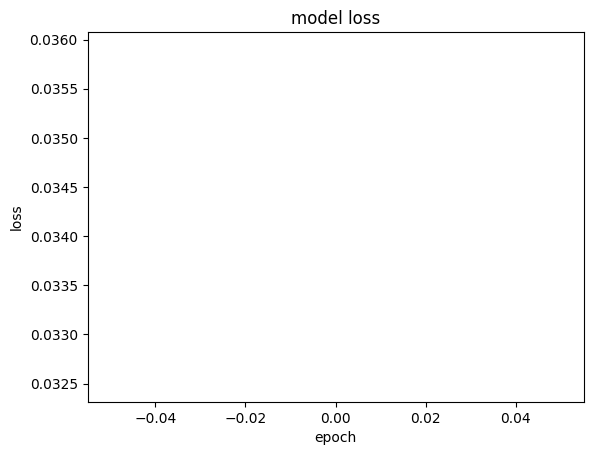

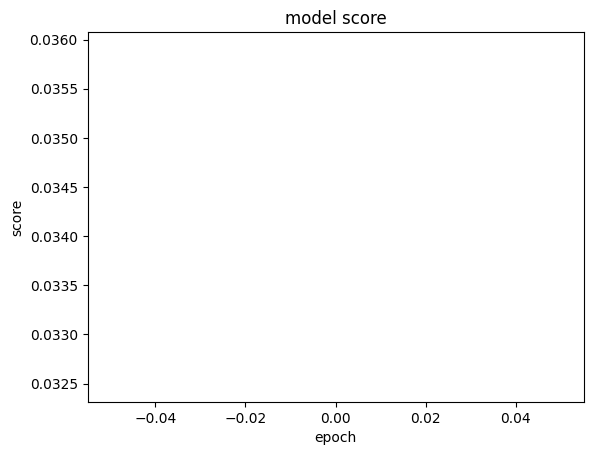

In [8]:
# @title Plot learning curves. { form-width: "30%" }

smoooth_window_half_width = 3

# For plotting learning curves.
losses_curve = history.history['loss']
scores_curve = history.history['root_mean_squared_error'] 

plt.plot(losses_curve)
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

plt.plot(losses_curve)
plt.title('model score')
plt.ylabel('score')
plt.xlabel('epoch')
plt.show()

### Model saving / loading

In [9]:
#model.save_weights('pifo_chk/final_checkpoint')


In [10]:
# schema = tfgnn.read_schema("pifo.pbtxt")
# graph_spec = tfgnn.create_graph_spec_from_schema_pb(schema)
# grid = LatLonGrid("dataset/202504.grib", 4)
# model = pifo(graph_spec,num_message_passing_steps=4,
#         num_mlp_hidden_layers=1,
#         mlp_hidden_size=8, # Pour mon petit modèle ça devrait être largement suffisant
#         latent_size=8, 
#         output_size=3)
# model.load_weights('./pifo_chk/final_checkpoint')


### Model saving / loading

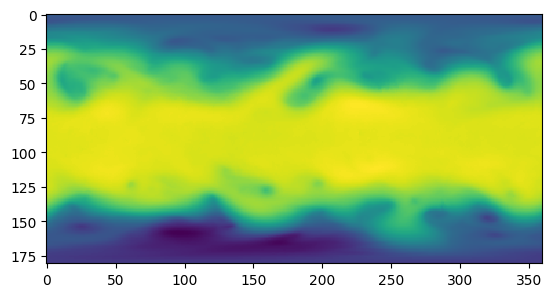

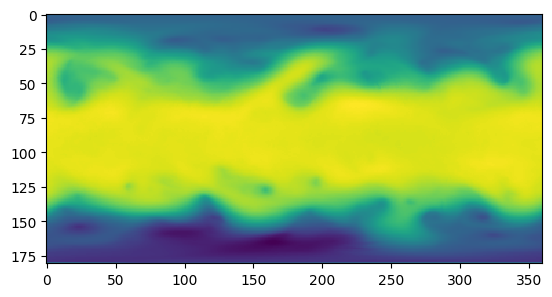

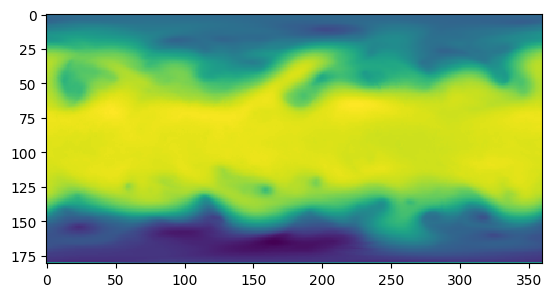

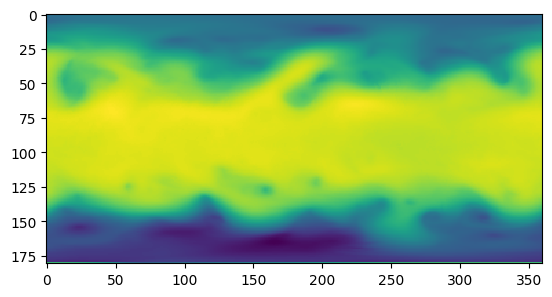

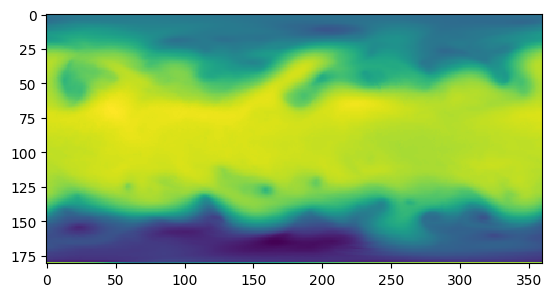

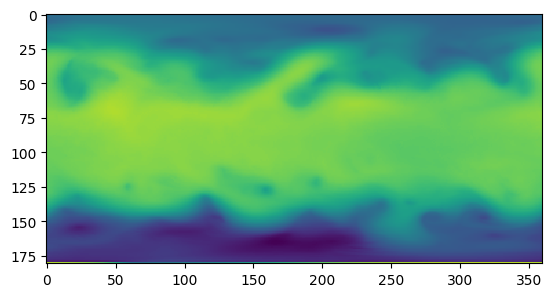

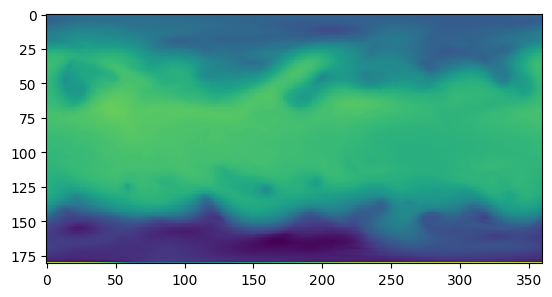

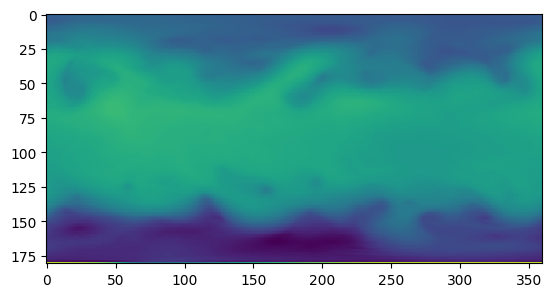

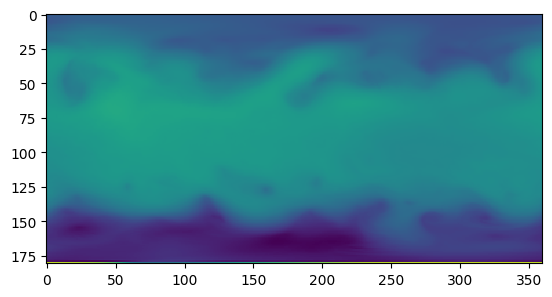

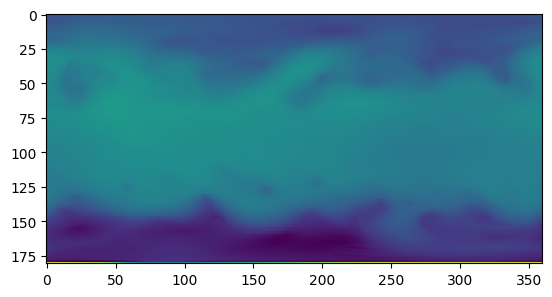

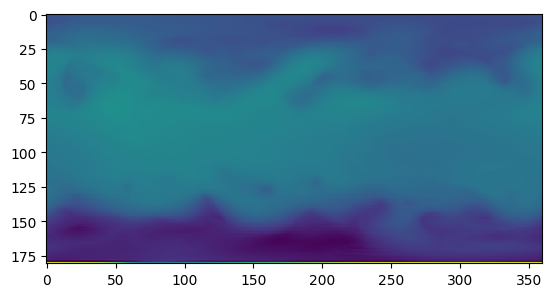

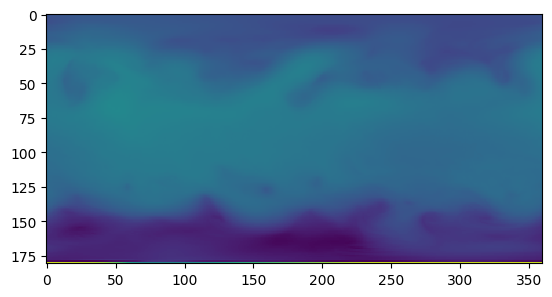

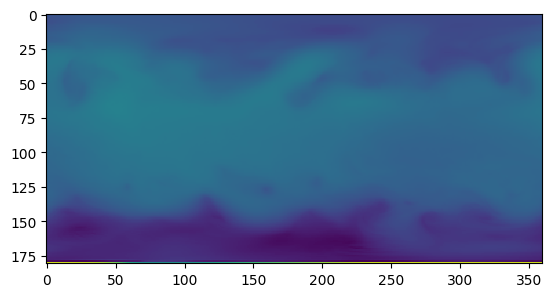

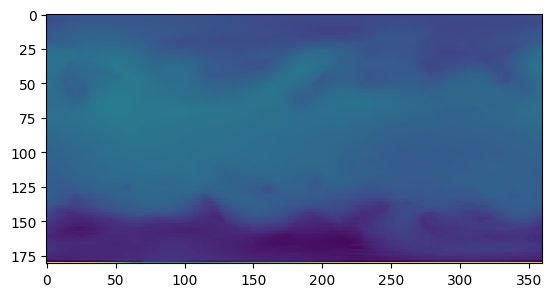

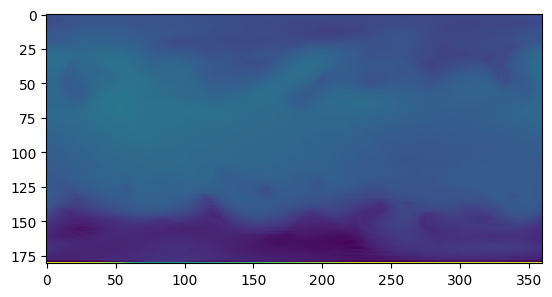

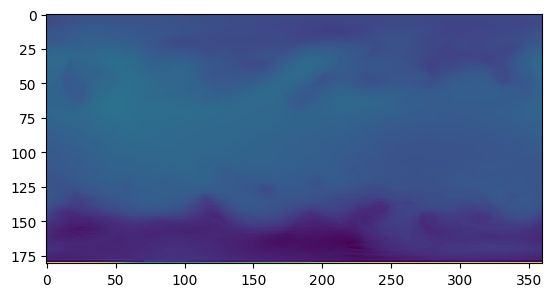

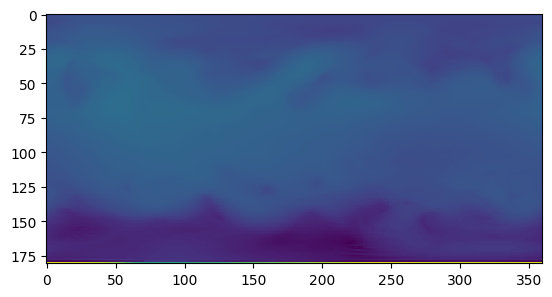

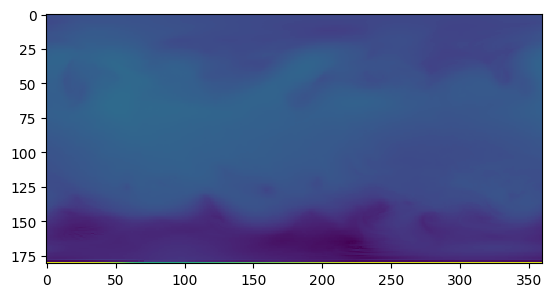

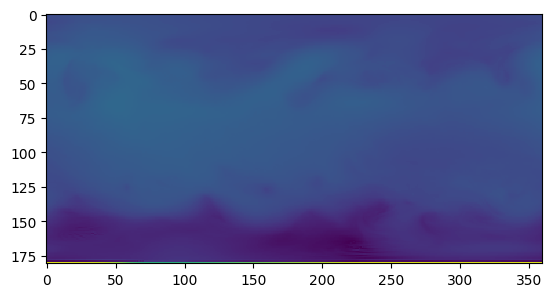

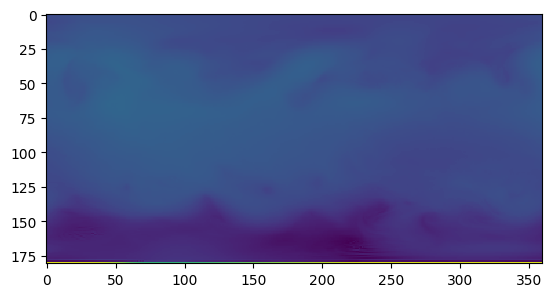

In [13]:
def plot(Y, width, height, fileName):
    img = tf.reshape(Y, [height, width])
    plt.imshow(img, interpolation='none')
    plt.show()
    plt.imsave(fileName, img)


graph, X = getGraphExample(grid)
Y = model(graph)
plot(X[:,0], grid.NLon, grid.NLat, "images/Y_0.png")


#print(G_NLon, G_NLat)
plot(Y[:,0], grid.NLon, grid.NLat, "images/Y_1.png")


for i in range(2,20):    
    graph = getGraphForFeatures(Y, grid)
    Y = model(graph)
    plot(Y[:,0], grid.NLon, grid.NLat, "images/Y_"+str(i)+".png")
